In [1]:
import sys
sys.path.append('../data')

import math, copy
import numpy as np
import matplotlib.pyplot as plt

from lab_utils_uni import (
    plt_intuition,
    plt_stationary,
    plt_update_onclick,
    soup_bowl,
    plt_house_x,
    plt_contour_wgrad,
    plt_divergence,
    plt_gradients
)

In [2]:
x_array = np.array([1.0,2.0])
y_array = np.array([300.0,500.0])
print(f"x_train  = {x_array}")
print(f"y_train  = {y_array}")


x_train  = [1. 2.]
y_train  = [300. 500.]


In [3]:
print(f"x_train.shape :  {x_array.shape}")
m = x_array.shape[0]
print(f"Number of Trainign Examples(m) : {m}")

x_train.shape :  (2,)
Number of Trainign Examples(m) : 2


In [4]:
i = 0
x_i = x_array[i]
y_i = y_array[i]
print(f"x ^({i}) , y ^ ({i}) = ({x_i} , {y_i})")
i = 1
x_i = x_array[i]
y_i = y_array[i]
print(f"x ^({i}) , y ^ ({i}) = ({x_i} , {y_i})")

x ^(0) , y ^ (0) = (1.0 , 300.0)
x ^(1) , y ^ (1) = (2.0 , 500.0)


In [5]:
for i in range(m):
    x_i = x_array[i]
    y_i = y_array[i]
    print(f"x ^({i}) , y ^ ({i}) = ({x_i} , {y_i})")


x ^(0) , y ^ (0) = (1.0 , 300.0)
x ^(1) , y ^ (1) = (2.0 , 500.0)


Text(0.5, 1.0, 'Housing Prices')

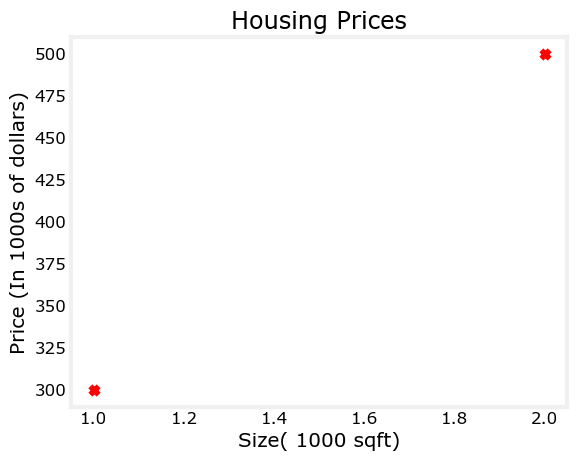

In [6]:
# Plotting

plt.scatter(x_array,y_array , marker= 'x' ,c = 'r')
plt.xlabel("Size( 1000 sqft)")
plt.ylabel("Price (In 1000s of dollars)")
plt.title("Housing Prices")



In [7]:
w = 200
b = 100
print(f"weights : {w}")
print(f"bias : {b}")

weights : 200
bias : 100


In [8]:
def compute_model_output(x , w, b):
    m  = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b

    return f_wb


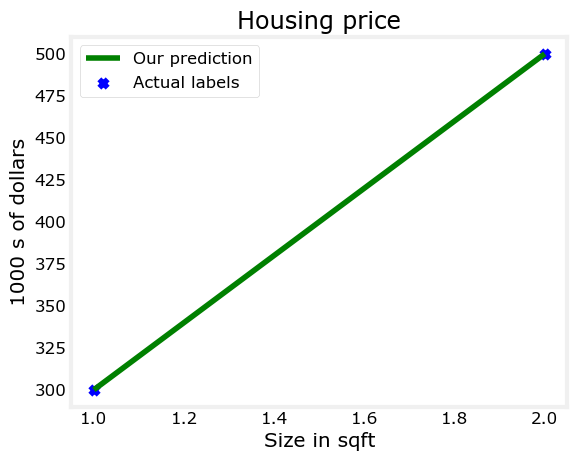

In [9]:
f_wb = compute_model_output(x_array,w,b)
plt.plot(x_array,f_wb , c = 'g' , label = "Our prediction")
plt.scatter(x_array,y_array, c = 'b' , label = "Actual labels" , marker='x')
plt.title("Housing price")
plt.ylabel("1000 s of dollars")
plt.xlabel("Size in sqft")
plt.legend()
plt.show()

In [10]:
def compute_cost(x ,y, w, b):
    m  = x.shape[0]
    f_wb = np.zeros(m)
    cost_sum = 0
    for i in range(m):
        f_wb[i] = w * x[i] + b
        cost  = (f_wb[i] - y[i]) ** 2
        cost_sum = cost_sum + cost
        total_cost = (1/(2 * m)) * cost_sum

    return total_cost


In [11]:
print(compute_cost(x_array,y_array,w,b))

0.0


In [12]:
plt_intuition(x_array,y_array)

interactive(children=(IntSlider(value=150, description='w', max=400, step=10), Output()), _dom_classes=('widge…

In [13]:
x_train = np.array([1.0, 1.7, 2.0, 2.5, 3.0, 3.2])
y_train = np.array([250, 300, 480,  430,   630, 730,])

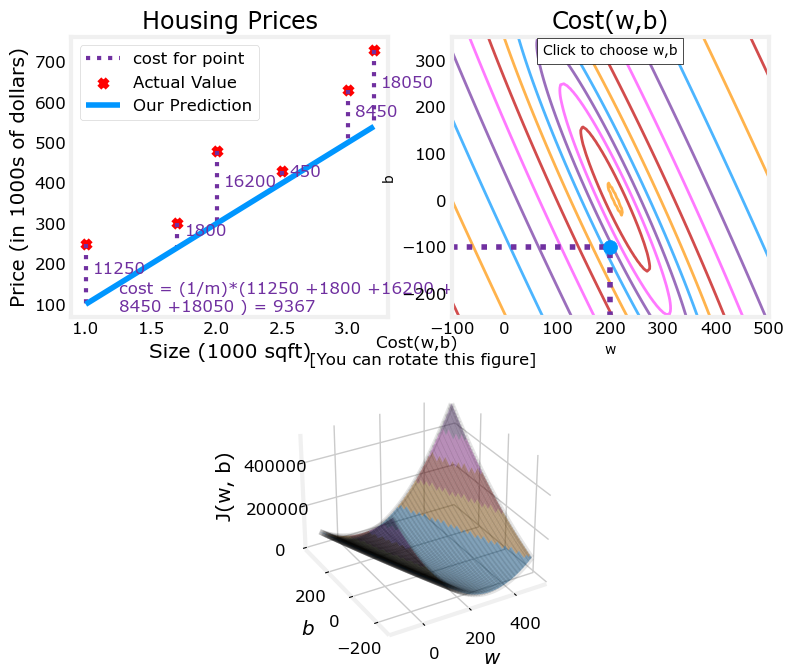

In [14]:
plt.close('all')
fig , ax ,dyn_items = plt_stationary(x_train,y_train)
updater = plt_update_onclick(fig,ax,x_train,y_train,dyn_items)

In [15]:
print("x_array:", x_array)
print("y_array:", y_array)
print("x_train:", x_train)
print("y_train:", y_train)

x_array: [1. 2.]
y_array: [300. 500.]
x_train: [1.  1.7 2.  2.5 3.  3.2]
y_train: [250 300 480 430 630 730]


In [16]:
print(compute_cost(x_array, y_array, 200, 100))
print(compute_cost(x_array, y_array, 200, -100))

0.0
20000.0


In [17]:
def compute_gradient(x,y,w,b):
    m = x.shape[0]
    dj_dw  = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw_i = (f_wb - y[i])*x[i]
        dj_db_i = f_wb - y[i]

        dj_dw += dj_dw_i
        dj_db += dj_db_i

    dj_dw = dj_dw/m
    dj_db = dj_db/m

    return dj_dw , dj_db


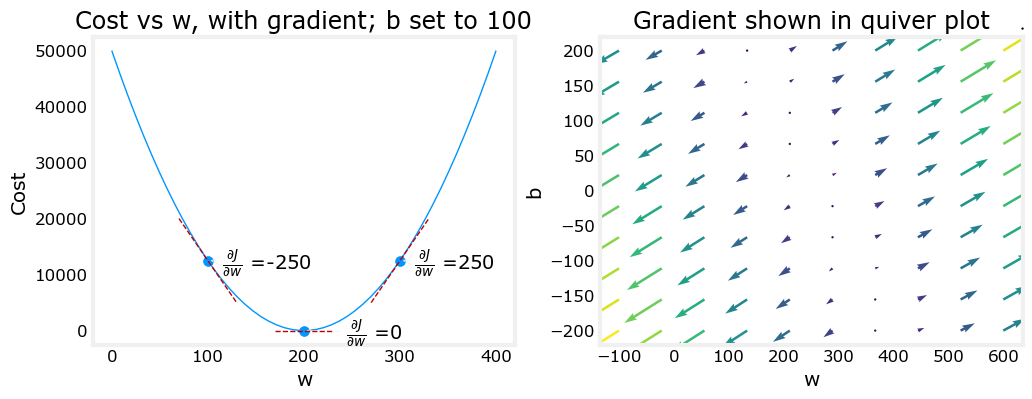

In [18]:
plt_gradients(x_array,y_array,compute_cost,compute_gradient)


In [19]:
def gradient_descent(x,y,w_in,b_in,alpha, num_iters, cost_function, gradient_function):
    J_history = []
    p_history = []
    b = b_in
    w = w_in

    for i in range(num_iters):
        dj_dw,dj_db = gradient_function(x,y,w,b)
        b = b - alpha * dj_db
        w = w - alpha * dj_dw
        if i < 100000:
            J_history.append(cost_function(x,y,w,b))
            p_history.append([w,b])
        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost{J_history[-1]:0.2e}",
                    f"dj_dw: {dj_dw : 0.3e},dj_db: {dj_db : 0.3e}",
                    f"w: {w : 0.3e} , b : {b: 0.5e}")
    return w, b, J_history,p_history


In [20]:
w_init = 0
b_init = 0
iterations = 10000
tmp_alpha = 1.0e-2

w_final,b_final,J_hist,p_hist = gradient_descent(x_array,y_array,w_init,b_init,tmp_alpha,iterations,compute_cost,compute_gradient)

Iteration    0: Cost7.93e+04 dj_dw: -6.500e+02,dj_db: -4.000e+02 w:  6.500e+00 , b :  4.00000e+00
Iteration 1000: Cost3.41e+00 dj_dw: -3.712e-01,dj_db:  6.007e-01 w:  1.949e+02 , b :  1.08228e+02
Iteration 2000: Cost7.93e-01 dj_dw: -1.789e-01,dj_db:  2.895e-01 w:  1.975e+02 , b :  1.03966e+02
Iteration 3000: Cost1.84e-01 dj_dw: -8.625e-02,dj_db:  1.396e-01 w:  1.988e+02 , b :  1.01912e+02
Iteration 4000: Cost4.28e-02 dj_dw: -4.158e-02,dj_db:  6.727e-02 w:  1.994e+02 , b :  1.00922e+02
Iteration 5000: Cost9.95e-03 dj_dw: -2.004e-02,dj_db:  3.243e-02 w:  1.997e+02 , b :  1.00444e+02
Iteration 6000: Cost2.31e-03 dj_dw: -9.660e-03,dj_db:  1.563e-02 w:  1.999e+02 , b :  1.00214e+02
Iteration 7000: Cost5.37e-04 dj_dw: -4.657e-03,dj_db:  7.535e-03 w:  1.999e+02 , b :  1.00103e+02
Iteration 8000: Cost1.25e-04 dj_dw: -2.245e-03,dj_db:  3.632e-03 w:  2.000e+02 , b :  1.00050e+02
Iteration 9000: Cost2.90e-05 dj_dw: -1.082e-03,dj_db:  1.751e-03 w:  2.000e+02 , b :  1.00024e+02


In [21]:
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

(w,b) found by gradient descent: (199.9929,100.0116)


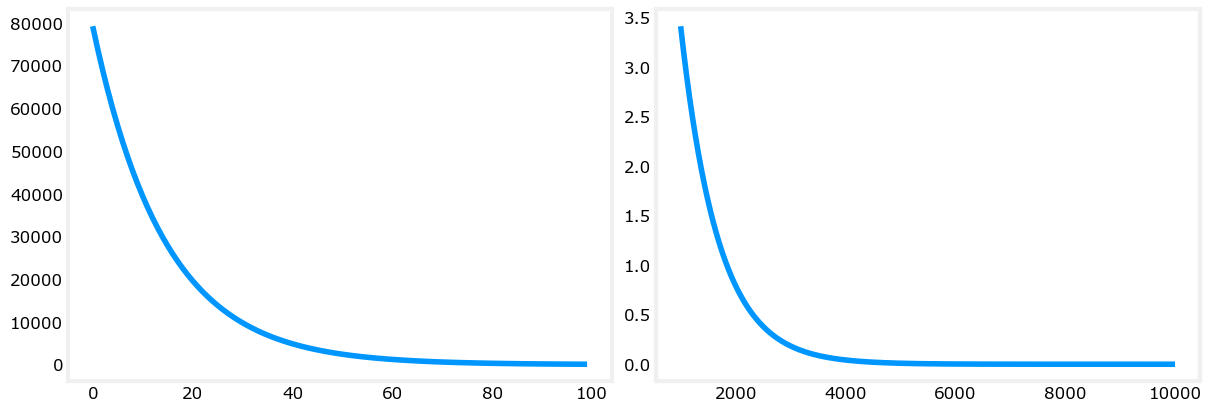

In [22]:
fig,(ax1,ax2) = plt.subplots(1,2, constrained_layout = True , figsize = (12,4) )
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])

In [23]:
print("Final Predication(1200 sqft) : " ,w_final*1.2 + b_final*1.1)

Final Predication(1200 sqft) :  350.0041454016794


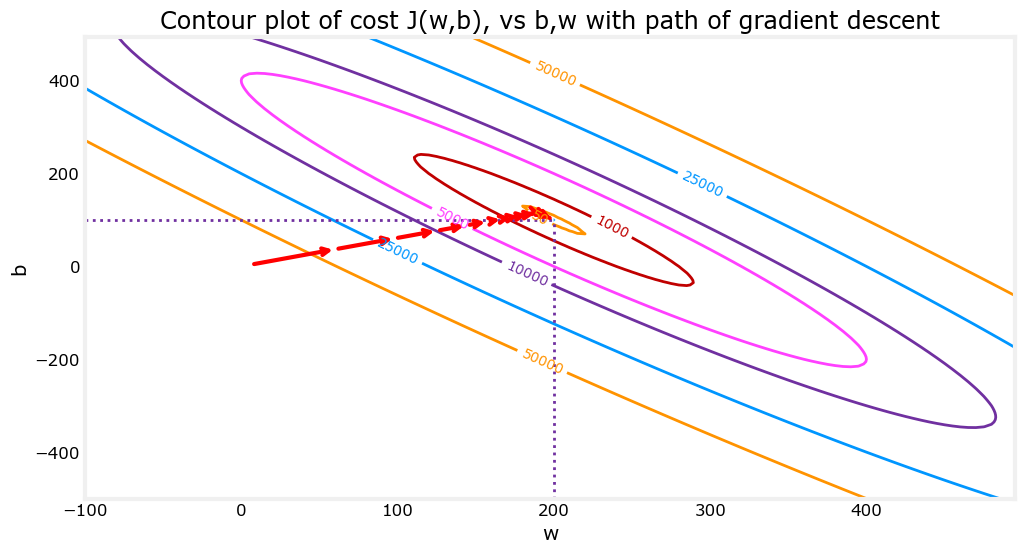

In [24]:
fig , ax = plt.subplots(1,1,figsize = (12,6))
plt_contour_wgrad(x_array,y_array,p_hist,ax)

In [25]:
w_init = 0
b_init = 0
iterations = 10
tmp_alpha = 8.0e-1

w_final,b_final,J_hist,p_hist = gradient_descent(x_array,y_array,w_init,b_init,tmp_alpha,iterations,compute_cost,compute_gradient)

Iteration    0: Cost2.58e+05 dj_dw: -6.500e+02,dj_db: -4.000e+02 w:  5.200e+02 , b :  3.20000e+02
Iteration    1: Cost7.82e+05 dj_dw:  1.130e+03,dj_db:  7.000e+02 w: -3.840e+02 , b : -2.40000e+02
Iteration    2: Cost2.37e+06 dj_dw: -1.970e+03,dj_db: -1.216e+03 w:  1.192e+03 , b :  7.32800e+02
Iteration    3: Cost7.19e+06 dj_dw:  3.429e+03,dj_db:  2.121e+03 w: -1.551e+03 , b : -9.63840e+02
Iteration    4: Cost2.18e+07 dj_dw: -5.974e+03,dj_db: -3.691e+03 w:  3.228e+03 , b :  1.98886e+03
Iteration    5: Cost6.62e+07 dj_dw:  1.040e+04,dj_db:  6.431e+03 w: -5.095e+03 , b : -3.15579e+03
Iteration    6: Cost2.01e+08 dj_dw: -1.812e+04,dj_db: -1.120e+04 w:  9.402e+03 , b :  5.80237e+03
Iteration    7: Cost6.09e+08 dj_dw:  3.156e+04,dj_db:  1.950e+04 w: -1.584e+04 , b : -9.80139e+03
Iteration    8: Cost1.85e+09 dj_dw: -5.496e+04,dj_db: -3.397e+04 w:  2.813e+04 , b :  1.73730e+04
Iteration    9: Cost5.60e+09 dj_dw:  9.572e+04,dj_db:  5.916e+04 w: -4.845e+04 , b : -2.99567e+04


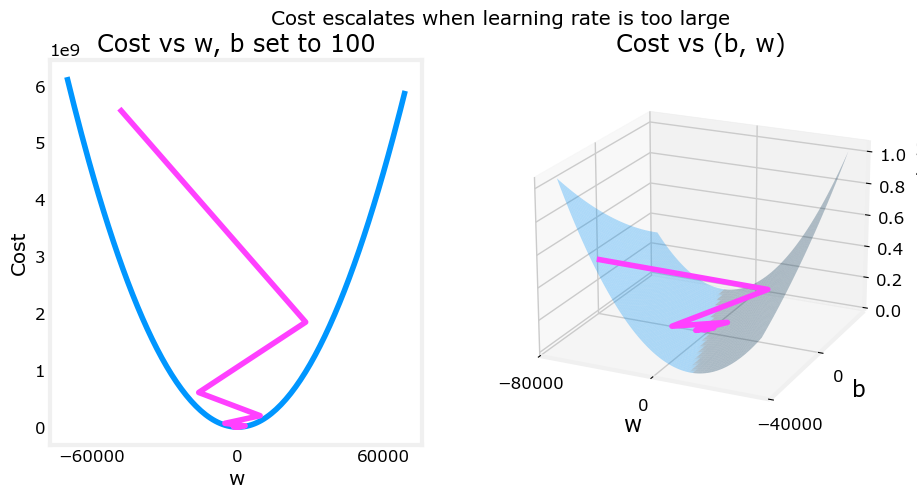

In [26]:
plt_divergence(p_hist,J_hist,x_array,y_array)